# Recurrence Quantification Analysis (CRQA)

In [ ]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/Users/cartersale/Research/Projects/Pose_Dynamics")
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
for mod in list(sys.modules):
    if mod == "pose_dynamics" or mod.startswith("pose_dynamics."):
        del sys.modules[mod]
importlib.invalidate_caches()

from pose_dynamics.nonlinear.rqa_utils import make_rqa_params, cross_rqa

# Load the subset exported earlier
PREPROC_PATH = Path(
    "/Users/cartersale/Research/Projects/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed_subset.csv"
)

df = pd.read_csv(PREPROC_PATH)
print(f"Loaded subset data: {df.shape}")
df.head()

KEYPOINTS_OF_INTEREST = [
    "left_ankle",
    "right_ankle",
    "left_wrist",
    "right_wrist",
    "nose",
]

# Group data by trial
trial_groups = dict(tuple(df.groupby("pair_trial")))
print(f"Found {len(trial_groups)} trials")

def compute_magnitude_xyz(df_trial: pd.DataFrame, base: str) -> np.ndarray:
    """Return magnitude of 3D keypoint position for one trial/party."""
    x = df_trial[f"{base}_x"].to_numpy()
    y = df_trial[f"{base}_y"].to_numpy()
    z = df_trial[f"{base}_z"].to_numpy()
    return np.sqrt(x**2 + y**2 + z**2)

ls_per_kp = {kp: [] for kp in KEYPOINTS_OF_INTEREST}

# signals_per_kp: kp -> list of 1D arrays (one per trial)
signals_per_kp = {kp: [] for kp in KEYPOINTS_OF_INTEREST}

for trial_id, df_trial in trial_groups.items():
    for kp in KEYPOINTS_OF_INTEREST:
        sig = compute_magnitude_xyz(df_trial, kp)

        # optional: skip extremely short segments
        if len(sig) < 200:  # tweak threshold if needed
            continue

        signals_per_kp[kp].append(sig)

for kp, lst in signals_per_kp.items():
    print(f"{kp}: {len(lst)} usable trials")

Loaded subset data: (455138, 25)
Found 216 trials
left_ankle: 216 usable trials
right_ankle: 216 usable trials
left_wrist: 216 usable trials
right_wrist: 216 usable trials
nose: 216 usable trials


## Cross on Subset of Keypoints

In [ ]:
# RQA parameters from parameter estimation notebook
EMB_DIM   = 4      # m
TAU       = 20     # τ
FIXED_RADIUS = 0.3 # Fixed radius for RQA

# Build base param dict with fixed radius
base_params = make_rqa_params(
    eDim=EMB_DIM,         # Embedding dimension from FNN
    tLag=TAU,             # Time lag from AMI
    radius=FIXED_RADIUS,  # Use fixed radius (not target %REC)
    norm="zscore",        # Z-score time series before RQA
    rescaleNorm=True,    
    tw=1,                 # Theiler window
    minl=4,               # minimal diagonal line length
)

def run_crqa_per_pair_trial(
    df: pd.DataFrame,
    params: dict,
    min_len: int = 200,
) -> pd.DataFrame:
    rows = []
    pair_ids = df["pair_trial"].unique()

    for pt in pair_ids:
        df_pair = df[df["pair_trial"] == pt].copy()

        parties = sorted(df_pair["party"].unique())
        if len(parties) != 2:
            print(f"[WARN] pair_trial {pt}: expected 2 parties, got {parties}")
            continue

        p1, p2 = parties[0], parties[1]
        df_p1 = df_pair[df_pair["party"] == p1]
        df_p2 = df_pair[df_pair["party"] == p2]

        meta_row = df_p1.iloc[0]
        pair_num   = meta_row.get("Pair", np.nan)
        trial_num  = meta_row.get("Trial", np.nan)
        condition  = meta_row.get("Condition", None)
        leader_id  = meta_row.get("Leader", None)

        for kp in KEYPOINTS_OF_INTEREST:
            x = compute_magnitude_xyz(df_p1, kp)
            y = compute_magnitude_xyz(df_p2, kp)

            L = min(len(x), len(y))
            if L < min_len:
                continue
            x = x[:L]
            y = y[:L]

            if L < (params["eDim"] * params["tLag"] + 5):
                continue

            try:
                td, rs, mats, err_code = cross_rqa(
                    x,
                    y,
                    params,
                    return_mats=False,
                )
            except Exception as e:
                print(f"[ERROR] CRQA failed for {pt}, {kp}: {e}")
                continue

            if err_code != 0:
                print(f"[WARN] CRQA error code={err_code} for {pt}, {kp}")
                continue

            row = {
                "pair_trial": pt,
                "Pair": pair_num,
                "Trial": trial_num,
                "Condition": condition,
                "Leader": leader_id,
                "party_p1": p1,
                "party_p2": p2,
                "keypoint": kp,
            }

            # Add ALL RQA metrics
            for k, v in rs.items():
                row[k] = v

            rows.append(row)

    return pd.DataFrame(rows)

crqa_df = run_crqa_per_pair_trial(
    df=df,
    params=base_params,
)

print(crqa_df.head())
print(crqa_df["keypoint"].value_counts())

# Check what recurrence rates we got with fixed radius
if not crqa_df.empty and "perc_recur" in crqa_df.columns:
    print("\nRecurrence rate distribution with fixed radius:")
    print(crqa_df["perc_recur"].describe())

# # Save results
OUTPUT_PATH = Path(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/rqa/mirror_game_crqa_results.csv"
)
crqa_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved CRQA results to: {OUTPUT_PATH}")

  pair_trial  Pair  Trial Condition Leader party_p1 party_p2     keypoint  \
0   P001_T10     1     10       uni     P2       P1       P2   left_ankle   
1   P001_T10     1     10       uni     P2       P1       P2  right_ankle   
2   P001_T10     1     10       uni     P2       P1       P2   left_wrist   
3   P001_T10     1     10       uni     P2       P1       P2  right_wrist   
4   P001_T10     1     10       uni     P2       P1       P2         nose   

   rescale  rad  ...  trend_lower_diag  trend_upper_diag  mean_line_length  \
0        1  0.3  ...         15.807287         10.774984         46.850887   
1        1  0.3  ...        -10.925272         -6.982358         12.431962   
2        1  0.3  ...         -6.735384         -3.090363          9.556276   
3        1  0.3  ...         -6.028357         -1.080247         10.893713   
4        1  0.3  ...         -9.508884         -4.251799         15.026638   

   std_line_length  count_line  laminarity  trapping_time  vmax  div

(array([  1.,   3.,   4.,  11.,  53.,  99.,  99., 104.,  81.,  72.,  50.,
         46.,  34.,  37.,  23.,  16.,  21.,  24.,  18.,  14.,  11.,  19.,
         13.,  19.,  11.,   8.,  11.,  10.,   8.,   8.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4,
        2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. ,
        5.2, 5.4, 5.6, 5.8, 6. ]),
 <BarContainer object of 30 artists>)

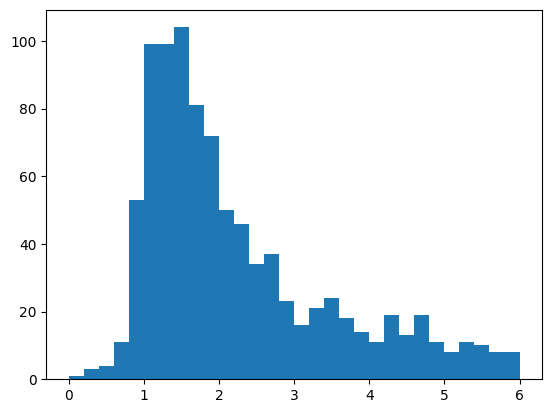

In [27]:
import matplotlib.pyplot as plt 
plt.hist(crqa_df["perc_recur"], bins=30, range=(0, 6))

## Cross Multivariate

In [22]:
import numpy as np
import pandas as pd

from pose_dynamics.nonlinear.rqa_utils import make_rqa_params, mv_cross_rqa

# ---------------------------------------------------------------------
# Helper: build multivariate time series per party
# ---------------------------------------------------------------------
def build_mv_series_for_party(
    df_party: pd.DataFrame,
    keypoints: list[str],
    min_len: int = 200,
) -> np.ndarray | None:
    """
    Build a multivariate series (T, D) for one party, using magnitude of each keypoint.
    Truncates all keypoints to the shortest length for that party.

    Returns:
        X : np.ndarray of shape (T, D) or None if too short.
    """
    series = []
    lengths = []

    for kp in keypoints:
        sig = compute_magnitude_xyz(df_party, kp)
        sig = np.asarray(sig, dtype=float).flatten()
        if sig.size == 0:
            continue
        series.append(sig)
        lengths.append(sig.size)

    if len(series) == 0:
        return None

    L = min(lengths)
    if L < min_len:
        return None

    # truncate and stack as columns -> (T, D)
    truncated = [s[:L] for s in series]
    X = np.column_stack(truncated)
    return X

# ---------------------------------------------------------------------
# Main MV-CRQA loop over pair_trial
# ---------------------------------------------------------------------
def run_mv_crqa_per_pair_trial(
    df: pd.DataFrame,
    params: dict,
    min_len: int = 200,
    target_rec: float | None = None,
) -> pd.DataFrame:
    """
    Multivariate cross-RQA between the two parties for each pair_trial.
    
    Uses the magnitudes of KEYPOINTS_OF_INTEREST as separate dimensions.

    Returns:
        DataFrame with one row per (pair_trial), containing MV-CRQA metrics.
    """
    rows = []
    pair_ids = df["pair_trial"].unique()

    for pt in pair_ids:
        df_pair = df[df["pair_trial"] == pt].copy()

        parties = sorted(df_pair["party"].unique())
        if len(parties) != 2:
            print(f"[WARN] pair_trial {pt}: expected 2 parties, got {parties}")
            continue

        p1, p2 = parties[0], parties[1]
        df_p1 = df_pair[df_pair["party"] == p1]
        df_p2 = df_pair[df_pair["party"] == p2]

        # common metadata from one row
        meta_row = df_p1.iloc[0]
        pair_num   = meta_row.get("Pair", np.nan)
        trial_num  = meta_row.get("Trial", np.nan)
        condition  = meta_row.get("Condition", None)
        leader_id  = meta_row.get("Leader", None)

        # build multivariate series for each party
        X1 = build_mv_series_for_party(df_p1, KEYPOINTS_OF_INTEREST, min_len=min_len)
        X2 = build_mv_series_for_party(df_p2, KEYPOINTS_OF_INTEREST, min_len=min_len)

        if X1 is None or X2 is None:
            # too short or missing
            continue

        # enforce same length across parties (truncate to shorter)
        L = min(X1.shape[0], X2.shape[0])
        if L < min_len:
            continue

        X1 = X1[:L, :]
        X2 = X2[:L, :]

        try:
            if target_rec is not None:
                # fixed-%REC mode (radius computed inside wrapper)
                td, rs, mats, err_code = mv_cross_rqa(
                    X1,
                    X2,
                    params,
                    return_mats=False,
                    target_rec=target_rec,
                )
            else:
                # fixed-radius mode (uses params["radius"])
                td, rs, mats, err_code = mv_cross_rqa(
                    X1,
                    X2,
                    params,
                    return_mats=False,
                )
        except Exception as e:
            print(f"[ERROR] MV-CRQA failed for {pt}: {e}")
            continue

        if err_code != 0:
            print(f"[WARN] MV-CRQA error code={err_code} for {pt}")
            continue

        row = {
            "pair_trial": pt,
            "Pair": pair_num,
            "Trial": trial_num,
            "Condition": condition,
            "Leader": leader_id,
            "party_p1": p1,
            "party_p2": p2,
            "dims": X1.shape[1],               # number of keypoints used
            "radius_used": rs.get("radius_used", np.nan),
            "mv_dim": rs.get("mv_dim", np.nan), # from wrapper
        }

        # add all RQA stats
        for k, v in rs.items():
            if k in row:
                continue
            row[k] = v

        rows.append(row)

    return pd.DataFrame(rows)

# ---------------------------------------------------------------------
# Params + run (fixed-radius mode)
# ---------------------------------------------------------------------
EMB_DIM   = 4
TAU       = 20

base_params_mv = make_rqa_params(
    eDim=EMB_DIM,   # ignored by multivariate backend, but harmless
    tLag=TAU,
    radius=0.3,     # <- fixed-radius
    norm="zscore",
    rescaleNorm=False,
    tw=1,
    minl=2,
)


mv_crqa_df = run_mv_crqa_per_pair_trial(
    df=df,
    params=base_params_mv,
    min_len=200,
)

if not mv_crqa_df.empty:
    print(mv_crqa_df["perc_recur"].describe())
    if "radius_used" in mv_crqa_df.columns:
        print(mv_crqa_df["radius_used"].describe())
else:
    print("mv_crqa_df is empty")


OUTPUT_PATH = Path(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/rqa/mirror_game_mv_crqa_results.csv"
)
mv_crqa_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved MV-CRQA results to: {OUTPUT_PATH}")


[WARN] MV-CRQA error code=2 for P006_T3
count    215.000000
mean       0.010904
std        0.021186
min        0.000177
25%        0.002494
50%        0.003961
75%        0.009011
max        0.180857
Name: perc_recur, dtype: float64
count    2.150000e+02
mean     3.000000e-01
std      1.112814e-16
min      3.000000e-01
25%      3.000000e-01
50%      3.000000e-01
75%      3.000000e-01
max      3.000000e-01
Name: radius_used, dtype: float64
Saved MV-CRQA results to: /Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/rqa/mirror_game_mv_crqa_results.csv


## Cross Multivaritate on all 38 Keypoints

In [ ]:
def infer_keypoints_from_df(df: pd.DataFrame) -> list[str]:
    """
    Infer all keypoint base names from columns like 'left_wrist_x', 'nose_y', etc.
    Assumes 3D pose: *_x, *_y, *_z.
    """
    kp_bases = {
        col.rsplit("_", 1)[0]
        for col in df.columns
        if col.endswith("_x")
    }
    return sorted(kp_bases)

def build_mv_series_for_party(
    df_party: pd.DataFrame,
    keypoints: list[str] | None = None,
    min_len: int = 200,
) -> np.ndarray | None:
    """
    Build a multivariate series (T, D) for one party, using magnitude of each keypoint.
    If keypoints is None, infer all keypoints from columns.

    Returns:
        X : np.ndarray of shape (T, D) or None if too short.
    """
    if keypoints is None:
        keypoints = infer_keypoints_from_df(df_party)

    series = []
    lengths = []

    for kp in keypoints:
        sig = compute_magnitude_xyz(df_party, kp)
        sig = np.asarray(sig, dtype=float).flatten()
        if sig.size == 0:
            continue
        series.append(sig)
        lengths.append(sig.size)

    if len(series) == 0:
        return None

    L = min(lengths)
    if L < min_len:
        return None

    truncated = [s[:L] for s in series]
    X = np.column_stack(truncated)
    return X

def run_mv_crqa_per_pair_trial(
    df: pd.DataFrame,
    params: dict,
    min_len: int = 200,
    target_rec: float | None = None,
) -> pd.DataFrame:
    rows = []
    pair_ids = df["pair_trial"].unique()

    for pt in pair_ids:
        df_pair = df[df["pair_trial"] == pt].copy()

        parties = sorted(df_pair["party"].unique())
        if len(parties) != 2:
            print(f"[WARN] pair_trial {pt}: expected 2 parties, got {parties}")
            continue

        p1, p2 = parties[0], parties[1]
        df_p1 = df_pair[df_pair["party"] == p1]
        df_p2 = df_pair[df_pair["party"] == p2]

        meta_row = df_p1.iloc[0]
        pair_num   = meta_row.get("Pair", np.nan)
        trial_num  = meta_row.get("Trial", np.nan)
        condition  = meta_row.get("Condition", None)
        leader_id  = meta_row.get("Leader", None)

        # --- NEW: use all keypoints (3D, so 38 dims -> 38 magnitudes) ---
        X1 = build_mv_series_for_party(df_p1, keypoints=None, min_len=min_len)
        X2 = build_mv_series_for_party(df_p2, keypoints=None, min_len=min_len)
        # ---------------------------------------------------------------

        if X1 is None or X2 is None:
            continue

        L = min(X1.shape[0], X2.shape[0])
        if L < min_len:
            continue

        X1 = X1[:L, :]
        X2 = X2[:L, :]

        try:
            if target_rec is not None:
                td, rs, mats, err_code = mv_cross_rqa(
                    X1,
                    X2,
                    params,
                    return_mats=False,
                    target_rec=target_rec,
                )
            else:
                td, rs, mats, err_code = mv_cross_rqa(
                    X1,
                    X2,
                    params,
                    return_mats=False,
                )
        except Exception as e:
            print(f"[ERROR] MV-CRQA failed for {pt}: {e}")
            continue

        if err_code != 0:
            print(f"[WARN] MV-CRQA error code={err_code} for {pt}")
            continue

        row = {
            "pair_trial": pt,
            "Pair": pair_num,
            "Trial": trial_num,
            "Condition": condition,
            "Leader": leader_id,
            "party_p1": p1,
            "party_p2": p2,
            "dims": X1.shape[1],
            "radius_used": rs.get("radius_used", np.nan),
            "mv_dim": rs.get("mv_dim", np.nan),
        }

        for k, v in rs.items():
            if k in row:
                continue
            row[k] = v

        rows.append(row)

    return pd.DataFrame(rows)


## Figures

Loaded fixed-effects table: /Users/cartersale/Research/Projects/Pose_Dynamics/projects/mirror_game/data/rqa/mixed_model_results_crqa.csv (44 rows)
Saved: /Users/cartersale/Research/Projects/Pose_Dynamics/projects/mirror_game/results/figures/crqa_feature_effects_entropy_lmax.svg


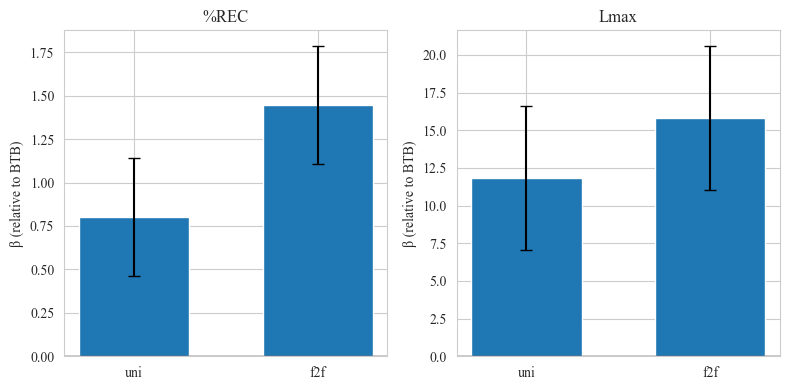

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# --- 1. Read fixed-effects output table from disk (no rerun needed) ---
TABLE_PATH = Path(
    "/Users/cartersale/Research/Projects/Pose_Dynamics/projects/mirror_game/data/rqa/mixed_model_results_crqa.csv"
)
fe_crqa = pd.read_csv(TABLE_PATH)
print(f"Loaded fixed-effects table: {TABLE_PATH} ({fe_crqa.shape[0]} rows)")

# Harmonize naming used in plotting
if "metric" in fe_crqa.columns and "feature" not in fe_crqa.columns:
    fe_crqa = fe_crqa.rename(columns={"metric": "feature"})

# --- 2. Keep only entropy + lmax (stored as maxl_found in this table) ---
metrics_plot_order = ["perc_recur", "maxl_found"]
metric_label_map = {
    "perc_recur": "%REC",
    "maxl_found": "Lmax",
}

fe_crqa = fe_crqa[fe_crqa["feature"].isin(metrics_plot_order)].copy()
fe_crqa = fe_crqa[fe_crqa["term"].isin(["Conditionuni", "Conditionf2f"])].copy()

# Condition labels
term_map = {"Conditionuni": "uni", "Conditionf2f": "f2f"}
fe_crqa["Condition"] = fe_crqa["term"].map(term_map)

# --- 3. Match linear-figure style ---
sns.set_style("whitegrid")
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["svg.fonttype"] = "path"

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

for ax, metric in zip(axes, metrics_plot_order):
    sub = fe_crqa[fe_crqa["feature"] == metric].copy()
    sub = sub.set_index("Condition").loc[["uni", "f2f"]].reset_index()

    ax.bar(
        x=sub["Condition"],
        height=sub["estimate"],
        yerr=sub["std.error"],
        capsize=4,
        width=0.6,
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("")
    ax.set_title(metric_label_map[metric])
    ax.set_ylabel("β (relative to BTB)")

plt.tight_layout()

out_path = (
    Path("/Users/cartersale/Research/Projects/Pose_Dynamics/projects/mirror_game/results/figures")
    / "crqa_feature_effects_entropy_lmax.svg"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300)
print(f"Saved: {out_path}")
plt.show()